Here, we repeat the visualizations in [Notebook 06Eii](./06Eii_Visualize_Embeddings.ipynb). However, we look at predictions with each component removed as generated in [Notebook 06Ei](./06Ei_get_predictions.ipynb). This will show us how the various changes in loss seend in Notebook 06Ei are associated with each component contributing accuracy to cell type vs categorical information. Our expectaiton is that the adjacency matrix will contribute to the stimulation information, whereas the bias will contribute to the cell type information. 

In [1]:
import os
import itertools

import pandas as pd
import scanpy as sc
import numpy as np

import torch

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

sys.path.insert(1, '../../.')
from Kang_utils import rev_stim, adata_dimviz_prediction


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load files from Notebook 06Ei:

In [5]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
tf_res_ = io.read_pickled_object(os.path.join(data_path, 'processed', author + '_predictions.pickle'))

Set up params:

In [ ]:
remove_components = ['none', 'global_bias', 'categorical_bias', 'total_bias', 'adj']
cell_types = [tc.split('^')[1] for tc in test_conds]
nrows = len(test_conds)
ncols = len(remove_components)

# 1. First 2 PCs for each counterfactual type and each prediction type:

In [18]:
counterfactual_type = 'opposite'

/tmp/ipykernel_3136518/66996603.py:62: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  fig.legend(handles=legend_actual.legendHandles,


''

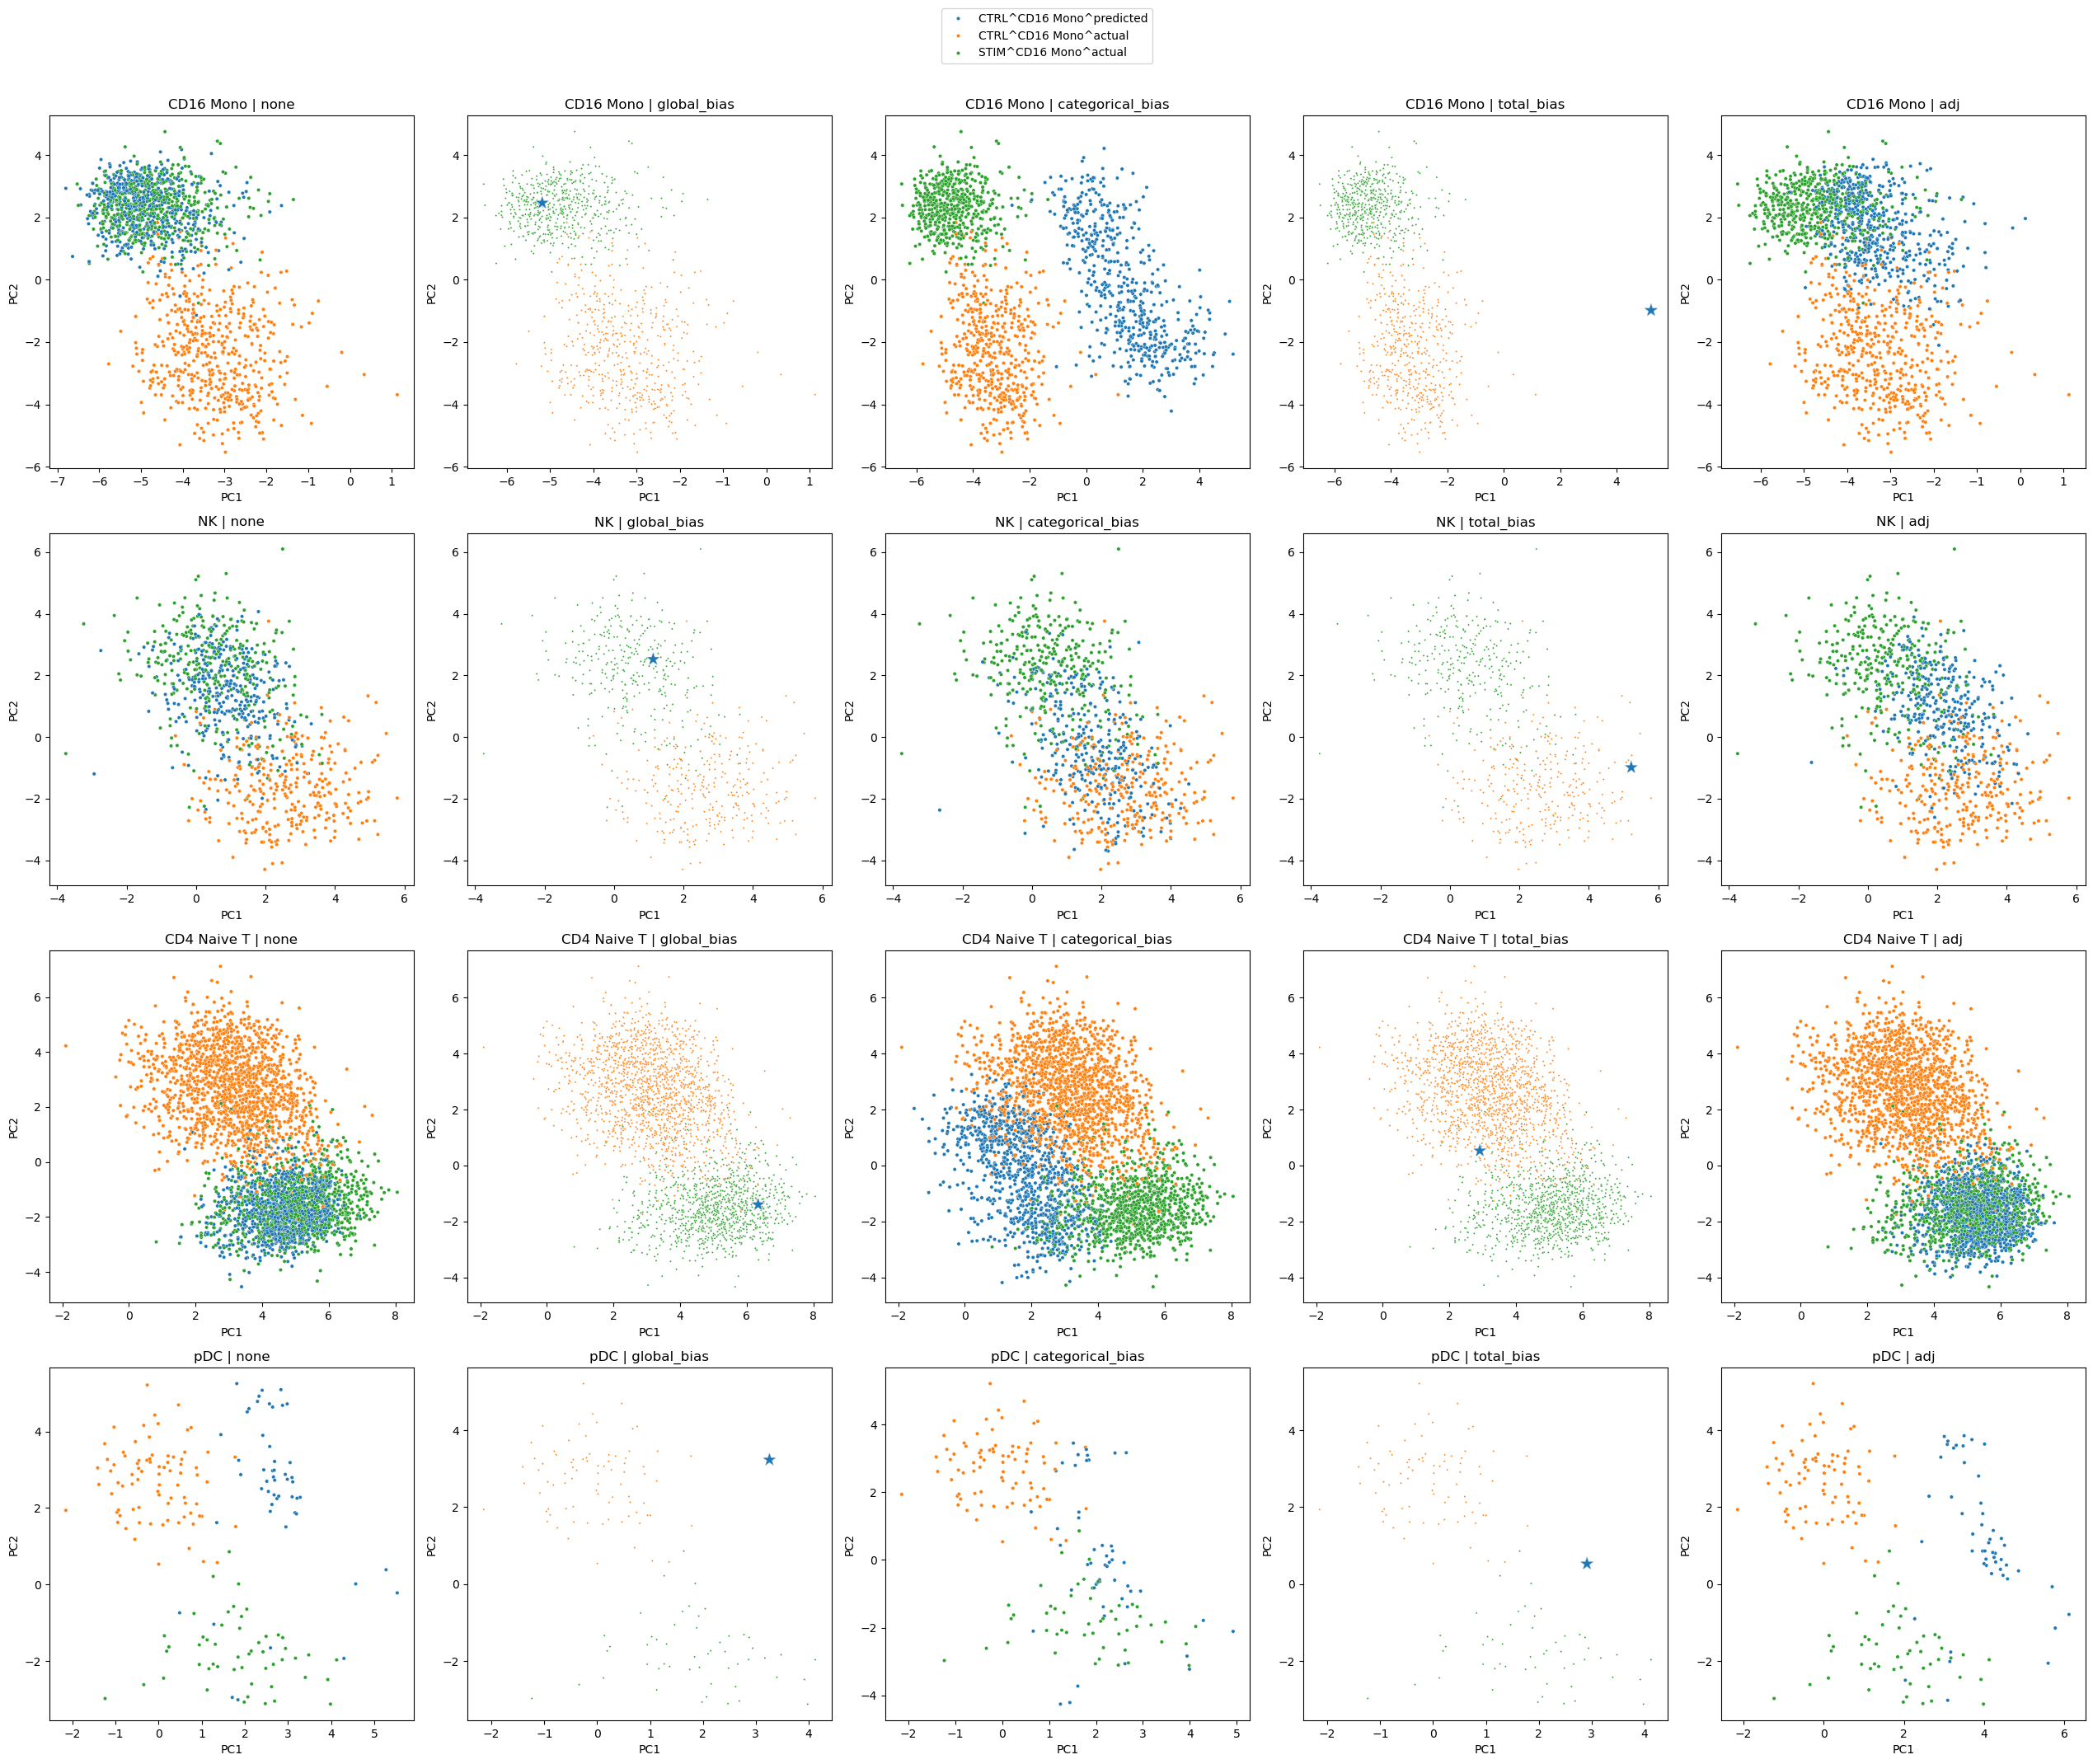

In [69]:
fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

for j, remove_component in enumerate(remove_components):
    
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[counterfactual_type][remove_component]
    
    tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

    tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['stim'] + '^' + 
        tf_adata_viz.obs['seurat_annotations'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                     seed = seed)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)


    for i, cell_type in enumerate(cell_types):
        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

        stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
        order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                stim_pred + '^' + cell_type + '^' + 'actual', 
                rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
        viz_df_ = viz_df_.copy()
        viz_df_.condition = pd.Categorical(viz_df_.condition, 
                                              categories = order, ordered=True)

        np.random.seed(seed)
        viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]
        
        if i == 0 and j == 0:
            legend = True
        else: 
            legend = False
        
        if remove_component in ['global_bias', 'total_bias']:
            sns.scatterplot(data = viz_df_, x = 'PC1', y = 'PC2', hue = 'condition',
                            size = 'batch', sizes={"actual": 10, "predicted": 150}, 
                            style = 'batch', markers={"actual": '.', "predicted": '*'}, 
                            ax = axes[i, j], legend = legend)
        else:
            sns.scatterplot(data = viz_df_, x = 'PC1', y = 'PC2', hue = 'condition', 
                    s=10, ax = axes[i, j], legend = legend)
        axes[i,j].set_title(cell_type + ' | ' + remove_component)
        
        
        if i == 0 and j == 0:
            legend_actual = axes[i,j].legend_  # Store the legend
            axes[i,j].legend_.remove() 
            
fig.legend(handles=legend_actual.legendHandles, 
           labels=[t.get_text() for t in legend_actual.get_texts()], 
           loc="upper center", bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
;

In [19]:
counterfactual_type = 'in_distribution'

/tmp/ipykernel_3136518/66996603.py:62: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  fig.legend(handles=legend_actual.legendHandles,


''

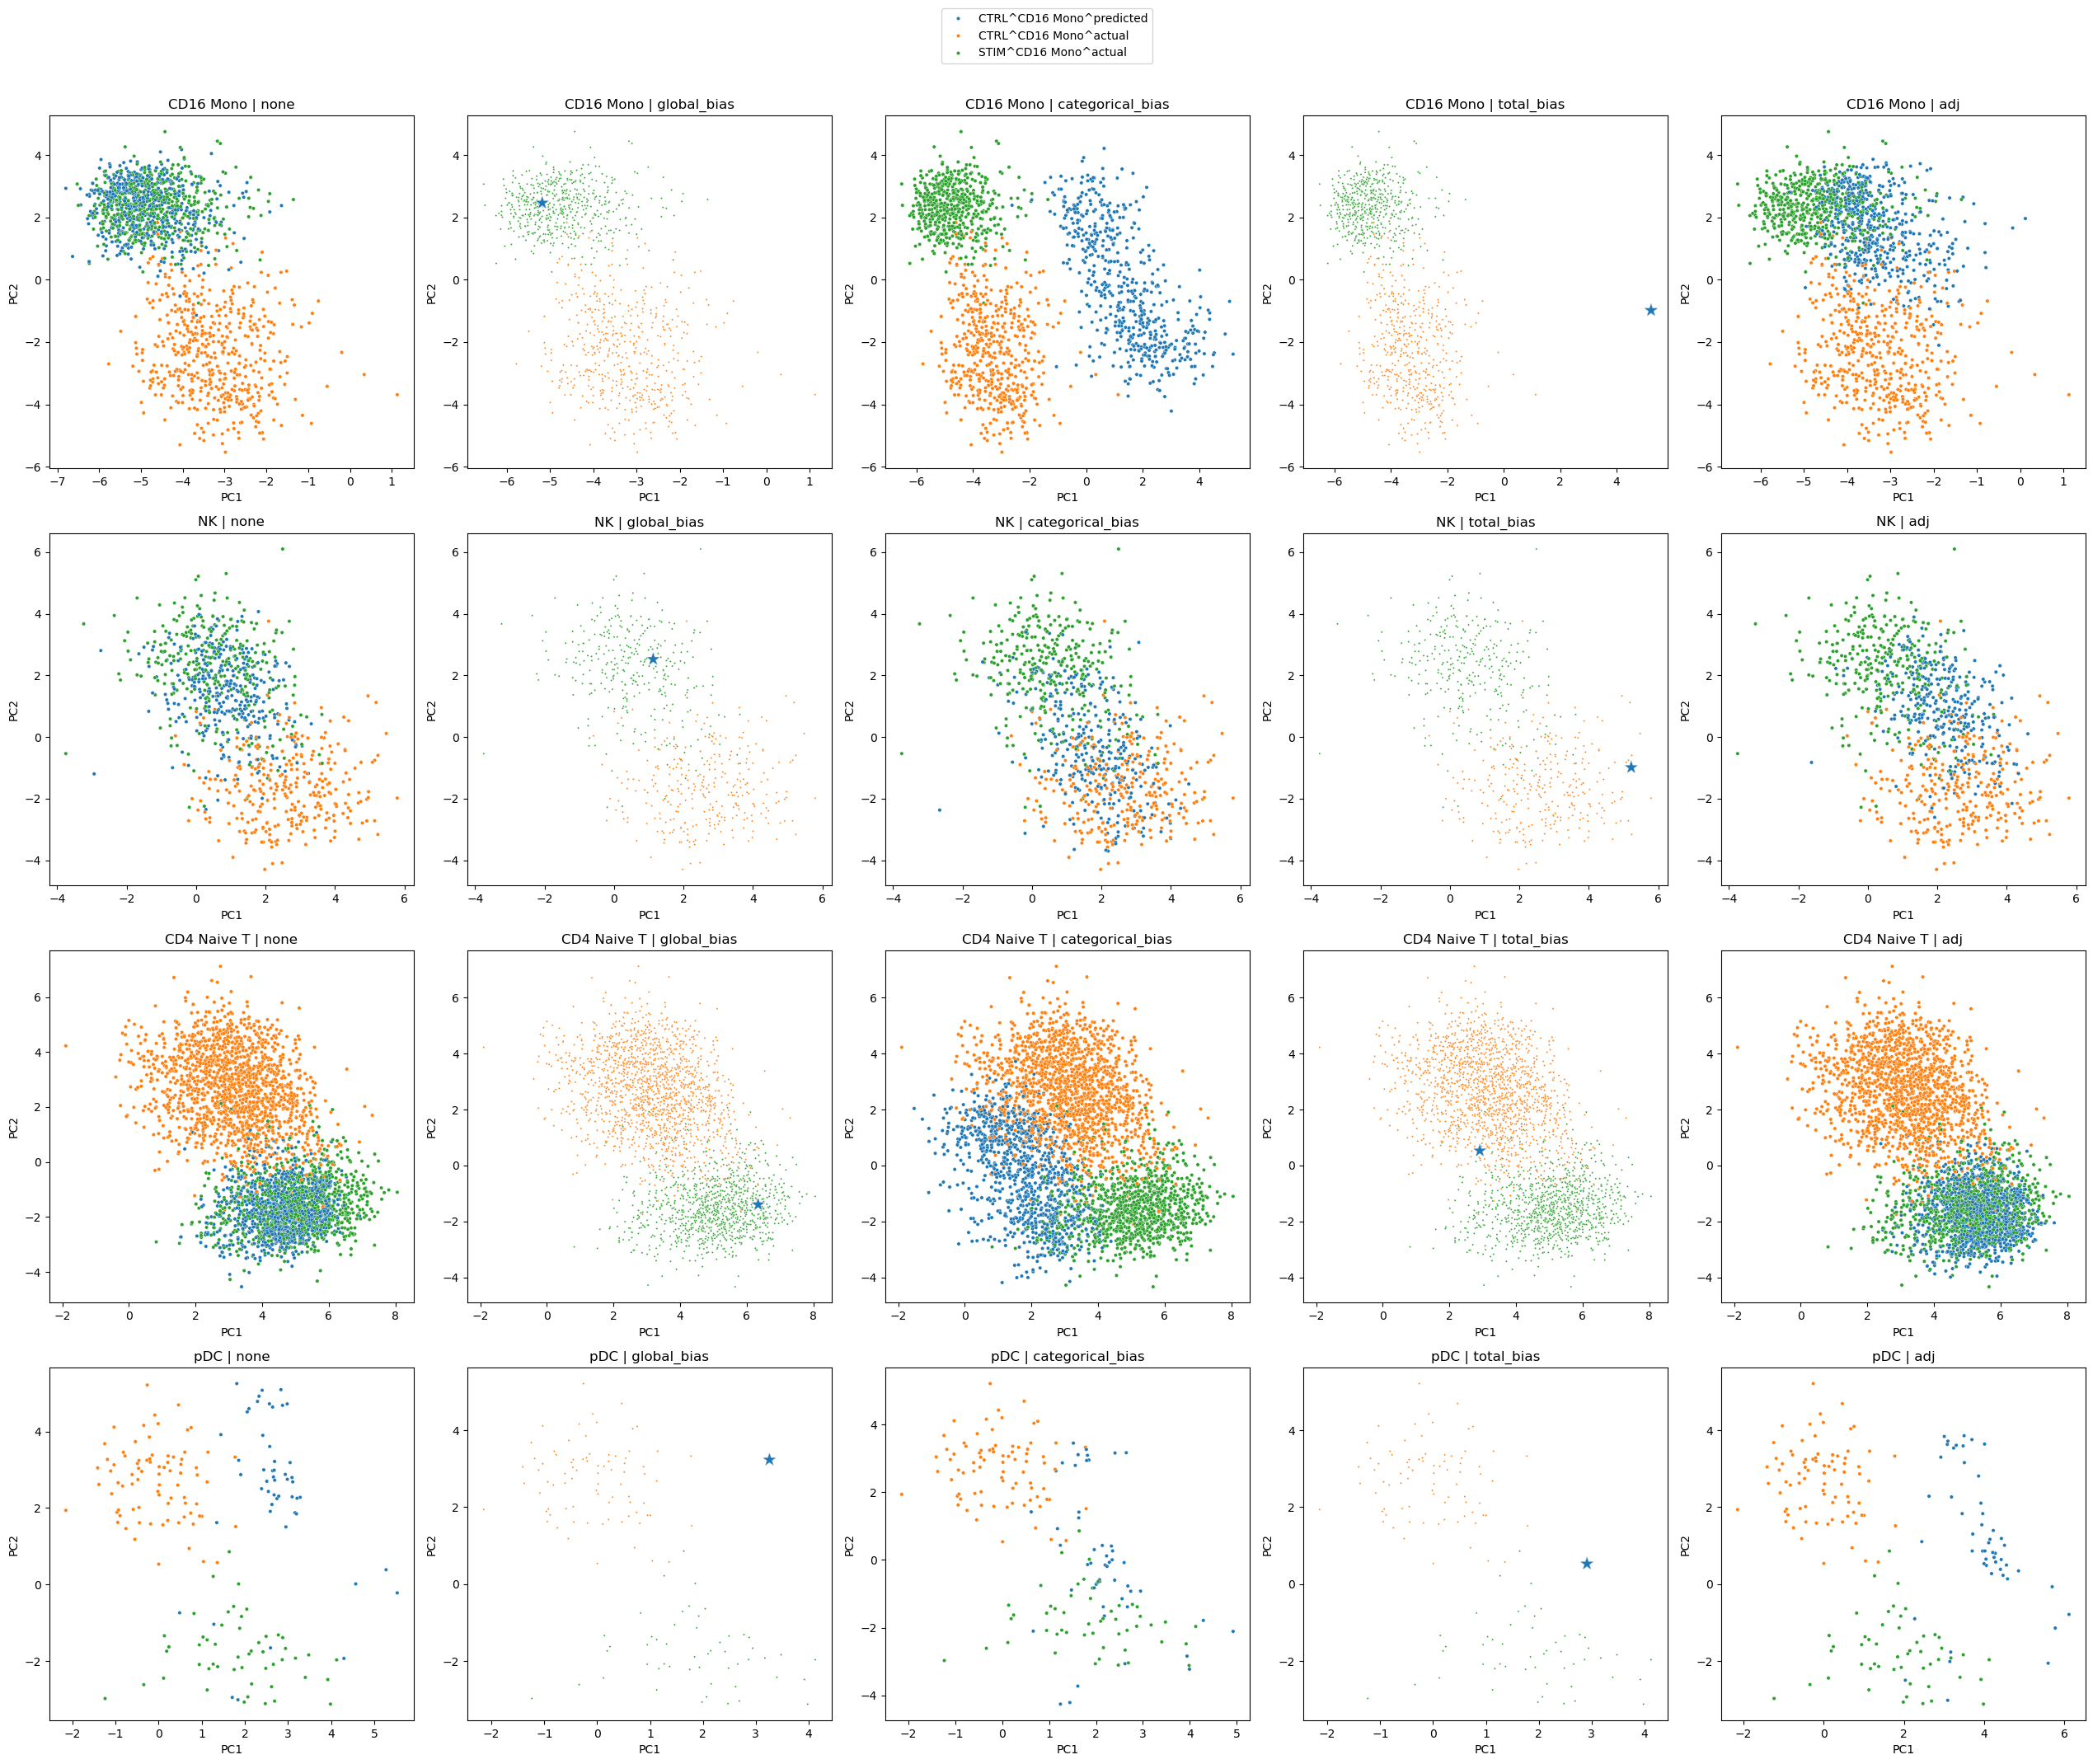

In [71]:
fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

for j, remove_component in enumerate(remove_components):
    
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[counterfactual_type][remove_component]
    
    tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

    tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['stim'] + '^' + 
        tf_adata_viz.obs['seurat_annotations'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 1000,
                                     seed = seed)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)


    for i, cell_type in enumerate(cell_types):
        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

        stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
        order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                stim_pred + '^' + cell_type + '^' + 'actual', 
                rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
        viz_df_ = viz_df_.copy()
        viz_df_.condition = pd.Categorical(viz_df_.condition, 
                                              categories = order, ordered=True)

        np.random.seed(seed)
        viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]
        
        if i == 0 and j == 0:
            legend = True
        else: 
            legend = False
        
        if remove_component in ['global_bias', 'total_bias']:
            sns.scatterplot(data = viz_df_, x = 'PC1', y = 'PC2', hue = 'condition',
                            size = 'batch', sizes={"actual": 10, "predicted": 150}, 
                            style = 'batch', markers={"actual": '.', "predicted": '*'}, 
                            ax = axes[i, j], legend = legend)
        else:
            sns.scatterplot(data = viz_df_, x = 'PC1', y = 'PC2', hue = 'condition', 
                    s=10, ax = axes[i, j], legend = legend)
        axes[i,j].set_title(cell_type + ' | ' + remove_component)
        
        
        if i == 0 and j == 0:
            legend_actual = axes[i,j].legend_  # Store the legend
            axes[i,j].legend_.remove() 
            
fig.legend(handles=legend_actual.legendHandles, 
           labels=[t.get_text() for t in legend_actual.get_texts()], 
           loc="upper center", bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
;

When removing global or total bias, that removes the variance in the data, so all predictions are the same (one single point).